<a href="https://colab.research.google.com/github/Viker05/-actividad-3-aprendizaje-/blob/main/Actividad_3_Segmentaci%C3%B3n_de_clientes_mediante_algoritmos_de_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# 1. Carga del dataset
df = pd.read_csv('clientes_clustering.csv')

# 2. Dimensiones
print(f'Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas')

# 3. Nombres de columnas y tipos de datos
print('\n--- Información general y tipos de datos ---')
print(df.info())

# 4. Muestra de los primeros registros
print('\n--- Primeros 5 registros ---')
print(df.head())

# 5. Valores faltantes y duplicados
print('\n--- Valores Faltantes ---')
print(df.isnull().sum())

print(f'\nRegistros duplicados exactos: {df.duplicated().sum()}')

# 6. Estadísticas descriptivas
print('\n--- Estadísticas Descriptivas ---')
print(df.describe().T)

# 7. Detección de posibles valores atípicos (Rango Intercuartílico - IQR)
num_cols = df.select_dtypes(include=[np.number]).columns
outliers_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_summary.append({
        'Variable': col,
        'Mínimo': df[col].min(),
        'Q1 (25%)': Q1,
        'Mediana (50%)': df[col].median(),
        'Q3 (75%)': Q3,
        'Máximo': df[col].max(),
        'Límite Inferior': lower_bound,
        'Límite Superior': upper_bound,
        'Outliers Detectados': outliers_count,
    })

df_outliers = pd.DataFrame(outliers_summary)
print('\n--- Resumen de Outliers (Método IQR) ---')
print(df_outliers.to_string(index=False))

Dimensiones del dataset: 1500 filas y 10 columnas

--- Información general y tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cliente_ID              1500 non-null   object 
 1   Edad                    1485 non-null   float64
 2   Antiguedad_Meses        1485 non-null   float64
 3   Compras_Mensuales       1500 non-null   int64  
 4   Gasto_Mensual_MXN       1485 non-null   float64
 5   Visitas_Mensuales       1485 non-null   float64
 6   Descuento_Promedio_Pct  1485 non-null   float64
 7   Devoluciones_6M         1500 non-null   int64  
 8   Dias_Ultima_Compra      1500 non-null   int64  
 9   Ticket_Promedio_MXN     1500 non-null   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 117.3+ KB
None

--- Primeros 5 registros ---
  Cliente_ID  Edad  Antiguedad_Meses  Compras_Mensuales  Gasto

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = pd.read_csv('clientes_clustering.csv')

# 2. Definir variables numéricas a utilizar (excluyendo Cliente_ID)
features = [
    'Edad',
    'Antiguedad_Meses',
    'Compras_Mensuales',
    'Gasto_Mensual_MXN',
    'Visitas_Mensuales',
    'Descuento_Promedio_Pct',
    'Devoluciones_6M',
    'Dias_Ultima_Compra',
    'Ticket_Promedio_MXN',
]

# 3. Tratamiento de valores faltantes mediante la Mediana
imputer = SimpleImputer(strategy='median')
df_imputed = df.copy()
df_imputed[features] = imputer.fit_transform(df[features])

# 4. Matriz de características X
X = df_imputed[features]

# 5. Escalamiento de características utilizando StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame para inspección
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print('--- Primeros 5 registros procesados y escalados ---')
print(X_scaled_df.head())

--- Primeros 5 registros procesados y escalados ---
       Edad  Antiguedad_Meses  Compras_Mensuales  Gasto_Mensual_MXN  \
0  1.145988          0.141034           0.489903           0.621324   
1 -0.638604          0.026123           0.489903          -0.018517   
2 -0.218700          0.887955          -0.239481           0.055377   
3  0.516132          0.083579          -0.968865          -1.028062   
4  0.096228         -0.720798          -0.968865          -0.843215   

   Visitas_Mensuales  Descuento_Promedio_Pct  Devoluciones_6M  \
0           0.658945               -0.611924        -0.956791   
1           1.248551               -0.037989        -0.956791   
2          -0.402348               -0.171224         0.882013   
3          -0.402348                0.751171        -0.956791   
4          -0.991955               -0.642670        -0.956791   

   Dias_Ultima_Compra  Ticket_Promedio_MXN  
0            0.242180             0.409475  
1           -1.026179            -0.7007

   K (Clusters)  Inercia (WCSS)  Silhouette Score
0             2         9275.94            0.2704
1             3         7537.69            0.2402
2             4         6721.08            0.2335
3             5         6253.01            0.2237
4             6         5923.24            0.2012
5             7         5620.33            0.1719
6             8         5362.91            0.1625


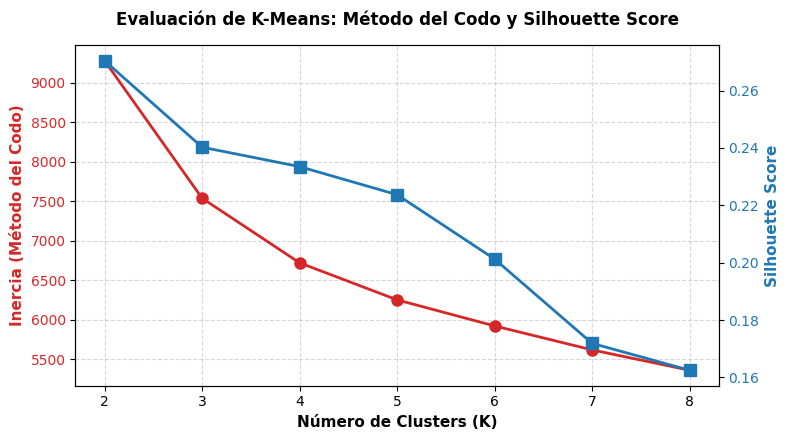

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Probar un rango de K de 2 a 8
k_values = list(range(2, 9))
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Inercia (Suma de errores cuadráticos internos)
    inertias.append(kmeans.inertia_)

    # Silhouette Score
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# 2. Presentar tabla de resultados
resultados_df = pd.DataFrame(
    {
        'K (Clusters)': k_values,
        'Inercia (WCSS)': np.round(inertias, 2),
        'Silhouette Score': np.round(silhouette_scores, 4),
    }
)
print(resultados_df)

# 3. Graficar Método del Codo y Silhouette Score
fig, ax1 = plt.subplots(figsize=(8, 4.5))

color = 'tab:red'
ax1.set_xlabel('Número de Clusters (K)', fontsize=11, fontweight='bold')
ax1.set_ylabel(
    'Inercia (Método del Codo)', color=color, fontsize=11, fontweight='bold'
)
ax1.plot(
    k_values,
    inertias,
    marker='o',
    color=color,
    linewidth=2,
    markersize=8,
    label='Inercia',
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel(
    'Silhouette Score', color=color, fontsize=11, fontweight='bold'
)
ax2.plot(
    k_values,
    silhouette_scores,
    marker='s',
    color=color,
    linewidth=2,
    markersize=8,
    label='Silhouette Score',
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(
    'Evaluación de K-Means: Método del Codo y Silhouette Score',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = pd.read_csv('clientes_clustering.csv')

# 2. Definir características
features = [
    'Edad',
    'Antiguedad_Meses',
    'Compras_Mensuales',
    'Gasto_Mensual_MXN',
    'Visitas_Mensuales',
    'Descuento_Promedio_Pct',
    'Devoluciones_6M',
    'Dias_Ultima_Compra',
    'Ticket_Promedio_MXN',
]

# 3. Preprocesamiento (Imputación y Escalamiento)
imputer = SimpleImputer(strategy='median')
df_imputed = df.copy()
df_imputed[features] = imputer.fit_transform(df[features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed[features])

# 4. Entrenar el modelo K-Means con K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Calcular conteos de clientes por clúster
counts = df['Cluster'].value_counts().sort_index()
percentages = (counts / len(df) * 100).round(2)

# 6. Variables para la tabla analítica
cols_analisis = [
    'Edad',
    'Compras_Mensuales',
    'Gasto_Mensual_MXN',
    'Visitas_Mensuales',
    'Descuento_Promedio_Pct',
    'Dias_Ultima_Compra',
    'Ticket_Promedio_MXN',
]

# 7. Generar tabla de promedios por Clúster
tabla_promedios = df.groupby('Cluster')[cols_analisis].mean().round(2)
tabla_promedios.insert(0, 'Cantidad_Clientes', counts)
tabla_promedios.insert(1, 'Porcentaje (%)', percentages)

# Imprimir la salida para la captura de pantalla
print('=== RESULTADOS DEL MODELO DEFINITIVO DE CLUSTERING (K=3) ===')
print(tabla_promedios.to_string())

=== RESULTADOS DEL MODELO DEFINITIVO DE CLUSTERING (K=3) ===
         Cantidad_Clientes  Porcentaje (%)   Edad  Compras_Mensuales  Gasto_Mensual_MXN  Visitas_Mensuales  Descuento_Promedio_Pct  Dias_Ultima_Compra  Ticket_Promedio_MXN
Cluster                                                                                                                                                                    
0                      356           23.73  41.50               8.14            6404.62              23.57                    7.25                6.13               816.52
1                      478           31.87  29.05               1.75             864.28               6.20                   17.62               37.92               566.26
2                      666           44.40  33.77               4.88            2620.23              17.67                   19.46               14.10               584.73


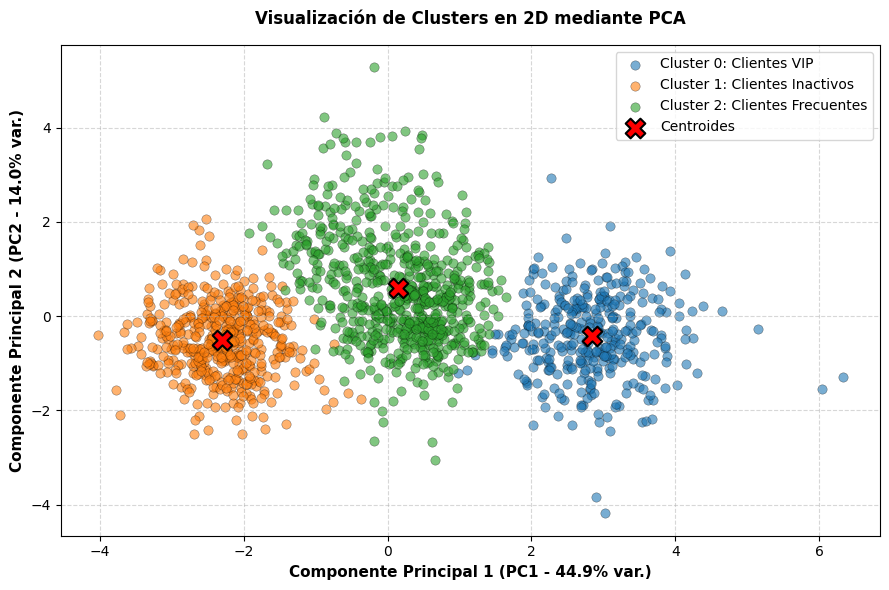

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = pd.read_csv('clientes_clustering.csv')

# 2. Definir características
features = [
    'Edad',
    'Antiguedad_Meses',
    'Compras_Mensuales',
    'Gasto_Mensual_MXN',
    'Visitas_Mensuales',
    'Descuento_Promedio_Pct',
    'Devoluciones_6M',
    'Dias_Ultima_Compra',
    'Ticket_Promedio_MXN',
]

# 3. Preprocesamiento (Imputación y Escalamiento)
imputer = SimpleImputer(strategy='median')
df_imputed = df.copy()
df_imputed[features] = imputer.fit_transform(df[features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed[features])

# 4. Entrenar el modelo K-Means con K = 3 (asumiendo K=3 es el óptimo elegido previamente)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Aplicar PCA para reducir las 9 variables a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Crear DataFrame con las proyecciones y la etiqueta del cluster
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# 6. Configurar la figura
plt.figure(figsize=(9, 6))
colores = {
    0: '#1f77b4',
    1: '#ff7f0e',
    2: '#2ca02c',
}  # Azul: VIP, Naranja: Inactivos, Verde: Frecuentes
etiquetas = {
    0: 'Cluster 0: Clientes VIP',
    1: 'Cluster 1: Clientes Inactivos',
    2: 'Cluster 2: Clientes Frecuentes',
}

# 7. Graficar cada clúster
for cluster_id in range(3):
    sub_df = df_pca[df_pca['Cluster'] == cluster_id]
    plt.scatter(
        sub_df['PC1'],
        sub_df['PC2'],
        c=colores[cluster_id],
        label=etiquetas[cluster_id],
        alpha=0.6,
        edgecolors='k',
        linewidth=0.3,
        s=45,
    )

# 8. Transformar y graficar los centroides en el espacio PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    s=200,
    c='red',
    marker='X',
    edgecolor='black',
    linewidth=1.5,
    label='Centroides',
)

# 9. Formato de la gráfica
plt.xlabel(
    f'Componente Principal 1 (PC1 - {pca.explained_variance_ratio_[0]*100:.1f}% var.)',
    fontsize=11,
    fontweight='bold',
)
plt.ylabel(
    f'Componente Principal 2 (PC2 - {pca.explained_variance_ratio_[1]*100:.1f}% var.)',
    fontsize=11,
    fontweight='bold',
)
plt.title(
    'Visualización de Clusters en 2D mediante PCA',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Aplicar Clustering Jerárquico Aglomerativo
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Cluster_Jerarquico'] = hierarchical.fit_predict(X_scaled)

# 2. Calcular Silhouette Score
sil_hierarchical = silhouette_score(X_scaled, df['Cluster_Jerarquico'])
print(f'Silhouette Score - Jerárquico: {sil_hierarchical:.4f}')

Silhouette Score - Jerárquico: 0.2367
